[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lshofsl/Advanced-topics-in-PoD-project-/blob/main/EBM_NCA_baseline.ipynb)

In [1]:
# Baseline NCA adapted
# @misc{guichard2025engramncaneuralcellularautomaton,
     # title={EngramNCA: a Neural Cellular Automaton Model of Memory Transfer},
     # author={Etienne Guichard and Felix Reimers and Mia Kvalsund and Mikkel Lepperød and Stefano Nichele},
     # year={2025},
     # eprint={2504.11855},
     # archivePrefix={arXiv},
     # primaryClass={cs.NE},
     # url={https://arxiv.org/abs/2504.11855},
#}


import os
import sys

!rm -rf Advanced-topics-in-PoD-project-
!git clone https://github.com/lshofsl/Advanced-topics-in-PoD-project-.git

repo_path = os.path.abspath("Advanced-topics-in-PoD-project-")
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

if os.path.exists(repo_path):
    print("Success! Files now found:", os.listdir(repo_path))

Cloning into 'Advanced-topics-in-PoD-project-'...
remote: Enumerating objects: 364, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 364 (delta 18), reused 19 (delta 7), pack-reused 322 (from 1)
Receiving objects: 100% (364/364), 12.59 MiB | 14.05 MiB/s, done.
Resolving deltas: 100% (203/203), done.
Success! Files now found: ['EBM_NCA_baseline.ipynb', 'EBM_NCA.ipynb', 'CRBM_NCA.ipynb', 'pathway.py', '.git', 'NCA.py', 'utils.py', 'NCA_baseline.py', 'README.md', 'Images']


In [2]:

#@title Imports { vertical-output: true}
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from NCA import *
import utils as utils
from IPython.display import Image, HTML, clear_output
import torch.nn.functional as F
import logging
from IPython.display import display, HTML, Video
from PIL import Image
import cv2
from base64 import b64encode
from sklearn.decomposition import PCA
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)


Using device: cuda


In [3]:
#@title Setup { vertical-output: true}
HEIGHT = 60 #@param {type:"integer"}
WIDTH = 60 #@param {type:"integer"}
CHANNELS = 16 # @param {type:"integer"}<--- NCA feature channels
BATCH_SIZE = 12 #@param {type:"integer"}
PADDING = 5 #@param {type:"integer"}
POOL_SIZE = 2666 #@param {type:"integer"}<--- NCA training pool size, lower values train faster but are less stable
TRAINING_ITERS = 8000  #@param {type:"integer"}<-- Number of trainign iterations
HIDDEN_SIZE = 64 #@param {type:"integer"}<--- NCA hidden size


style = """
<style>
.output_wrapper, .output {
    display: flex;
    flex-direction: row-reverse; /* Align content to the right */
}
</style>
"""


In [4]:
#@title Load Primitives { vertical-output: true}

LIZARD = "Images/lizard.png"
path = LIZARD
image, image_to_display = utils.get_image(os.path.join(repo_path, path), HEIGHT, WIDTH, padding=PADDING)

HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING


In [5]:
class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

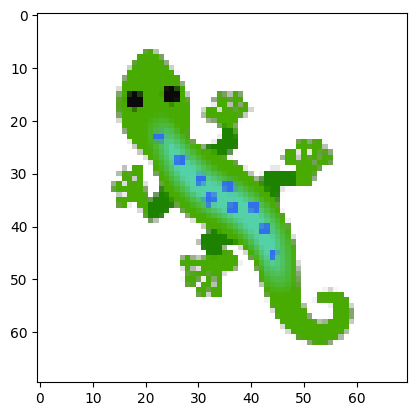

In [6]:
#@title Display Primitives { vertical-output: true}
seed = np.zeros([CHANNELS, HEIGHT, WIDTH], np.float32)
seed[3:, HEIGHT // 2, WIDTH // 2] = 1.0

pool = SamplePool(x=np.repeat(seed[None, ...], POOL_SIZE, axis=0))


plt.imshow(image_to_display)
plt.show()


In [7]:
#@title Get Batch Image Partitions { vertical-output: true}
batch = pool.sample(BATCH_SIZE)

In [8]:
#@title Load Filters for Loss Function { vertical-output: true}

sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32, device=DEVICE)
lap = torch.tensor([[1.0, 2.0, 1.0], [2.0, -12, 2.0], [1.0, 2.0, 1.0]], dtype=torch.float32, device=DEVICE)
filters = torch.stack([sobel_x, sobel_x.T, lap])
folder = "Gene"

In [9]:
#@title Create Path for Saving Models { vertical-output: true}
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")


Path: Trained_models/Gene created


In [10]:
#@title Initialise NCA { vertical-output: true}
base = image.tile(BATCH_SIZE, 1, 1, 1).to(DEVICE)
loss_log = []
nca = GeneCA(CHANNELS,HIDDEN_SIZE)
nca = nca.to(DEVICE)
optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)
name = folder + "/" +type(nca).__name__

Batch


/tmp/ipykernel_465/3408540574.py:78: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(10, 4))


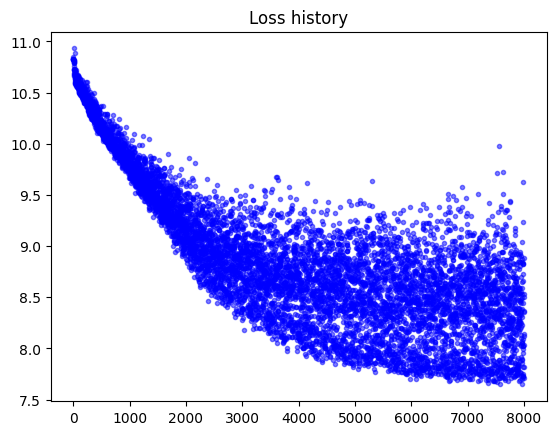

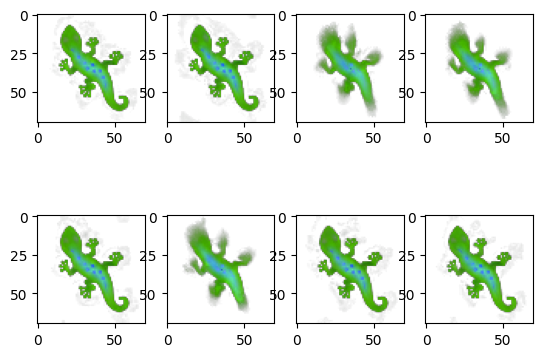

Trained_models/Gene/GeneCA.pth


In [11]:
#@title Training { vertical-output: true}

hidden_layers = []
hidden_corr = []
hidden_layers_iters = []
pca_maps = []
pca = None
PCA_REFIT_EVERY = 500
LOG_HIDDEN_EVERY = 100

for i in range(TRAINING_ITERS + 1):
    with torch.no_grad():
        batch = pool.sample(BATCH_SIZE)
        x = torch.from_numpy(batch.x).to(DEVICE)

    for _ in range(random.randrange(32, 92)):
        x = nca(x)

    per_sample_loss = (base - x[:, :4, :, :]).pow(2).sum(dim=[1, 2, 3])
    reg = 0.1 * (
        perchannel_conv(base, filters) - perchannel_conv(x[:, :4, :, :], filters)
    ).pow(2).sum()
    loss = per_sample_loss.sum() + reg

    loss.backward()
    with torch.no_grad():
        for p in nca.parameters():
            p.grad /= (p.grad.norm() + 1e-8)
        optim.step()
        x = x.detach()
        optim.zero_grad()

    loss_log.append(loss.log().item())
    with torch.no_grad():
        loss_rank = per_sample_loss.detach().cpu().numpy().argsort()[::-1]  # worst first
        x_np = x.detach().cpu().numpy()[loss_rank]
        x_np[:1] = seed  # reseed the single worst sample
        batch.x[:] = x_np
        batch.commit()
    scheduler.step()

    with torch.no_grad():
        visible = x[:, :4, :, :]
        hidden = x[:, 4:16, :, :]

        B, n_vis, H, W = visible.shape
        n_hid = hidden.shape[1]

        v_flat = visible.permute(0, 2, 3, 1).reshape(-1, n_vis)
        h_flat = hidden.permute(0, 2, 3, 1).reshape(-1, n_hid)

        living_mask = v_flat[:, 3] > 0.1

        if living_mask.sum() < 10:
            hidden_corr.append(float('nan'))
        else:
            h_live = h_flat[living_mask].cpu().numpy()
            if n_hid > 1:
                cc_hh = np.abs(np.corrcoef(h_live, rowvar=False))
                hh_val = np.mean(cc_hh[np.triu_indices(n_hid, k=1)])
            else:
                hh_val = 0.0
            hidden_corr.append(hh_val)

            if i % LOG_HIDDEN_EVERY == 0:
                hidden_layers.append(h_live)
                hidden_layers_iters.append(i)

        if i % PCA_REFIT_EVERY == 0 and len(hidden_layers) > 0:
            pooled = np.concatenate(hidden_layers, axis=0)
            pca = PCA(n_components=2)
            pca.fit(pooled)

    if i % 100 == 0:
        print(f"Training itter {i}, loss = {loss.item()}")
        plt.clf()
        clear_output()
        plt.figure(1, figsize=(10, 4))
        plt.title('Loss history')
        plt.plot(loss_log, '.', alpha=0.5, color="b")
        print("Batch")
        utils.show_batch(x[2:14])
        display(HTML(style))
        plt.show(block=False)
        plt.pause(0.01)

    if pca is not None and i % 10 == 0:
        grid0_hidden = hidden[0]
        grid0_alive = (visible[0, 3] > 0.1).cpu().numpy()

        h_grid_flat = grid0_hidden.permute(1, 2, 0).reshape(-1, n_hid).cpu().numpy()
        proj = pca.transform(h_grid_flat)
        PC1_map = proj[:, 0].reshape(H, W)
        PC2_map = proj[:, 1].reshape(H, W)

        pca_maps.append((i, PC1_map, PC2_map, grid0_alive))

    if i % 100 == 0:
        torch.save(nca.state_dict(), "Trained_models/" + name + ".pth")
        print("Trained_models/" + name + ".pth")


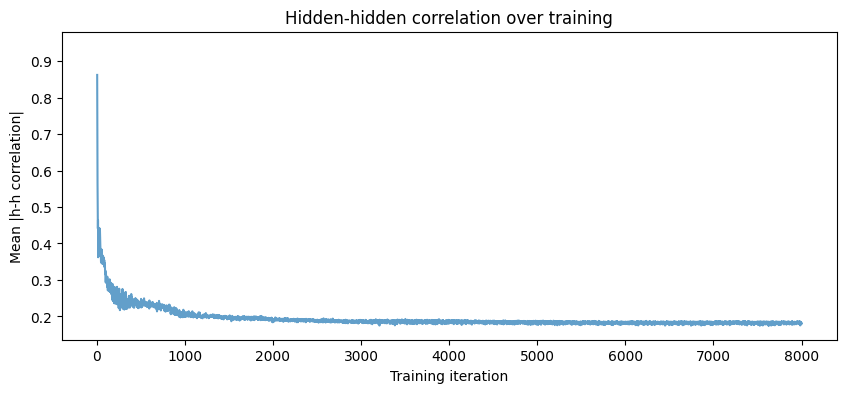

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(hidden_corr, alpha=0.7)
plt.xlabel("Training iteration")
plt.ylabel("Mean |h-h correlation|")
plt.title("Hidden-hidden correlation over training")
plt.show()

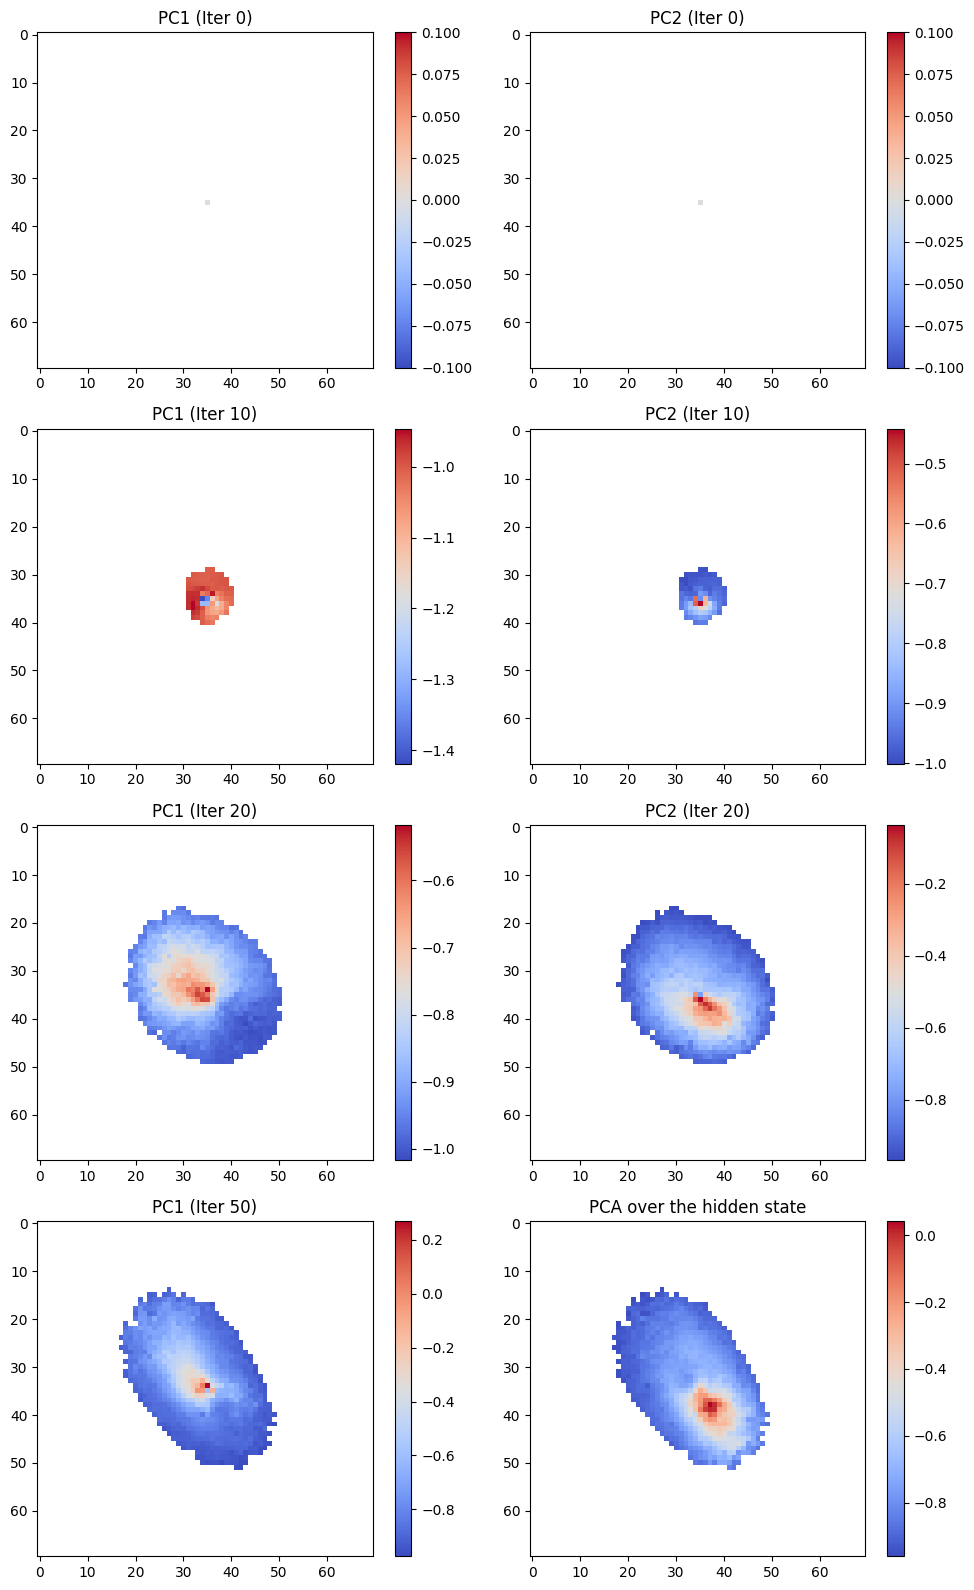

In [15]:
pca_maps_by_iter = {it: (PC1_map, PC2_map, alive_mask) for (it, PC1_map, PC2_map, alive_mask) in pca_maps}

requested_iters = [0, 10, 20, 50]
available_iters = [it for it in requested_iters if it in pca_maps_by_iter]

num_rows = len(available_iters)
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 4 * num_rows))

if num_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, it in enumerate(available_iters):
    PC1_map, PC2_map, alive_mask = pca_maps_by_iter[it]

    for col_idx, (pc_map, name) in enumerate(zip([PC1_map, PC2_map], ['PC1', 'PC2'])):
        ax = axes[row_idx, col_idx]
        masked = np.where(alive_mask, pc_map, np.nan)

        im = ax.imshow(masked, cmap='coolwarm')
        ax.set_title(f"{name} (Iter {it})")

        fig.colorbar(im, ax=ax)
plt.title("PCA over the hidden state")
plt.tight_layout()
plt.show()


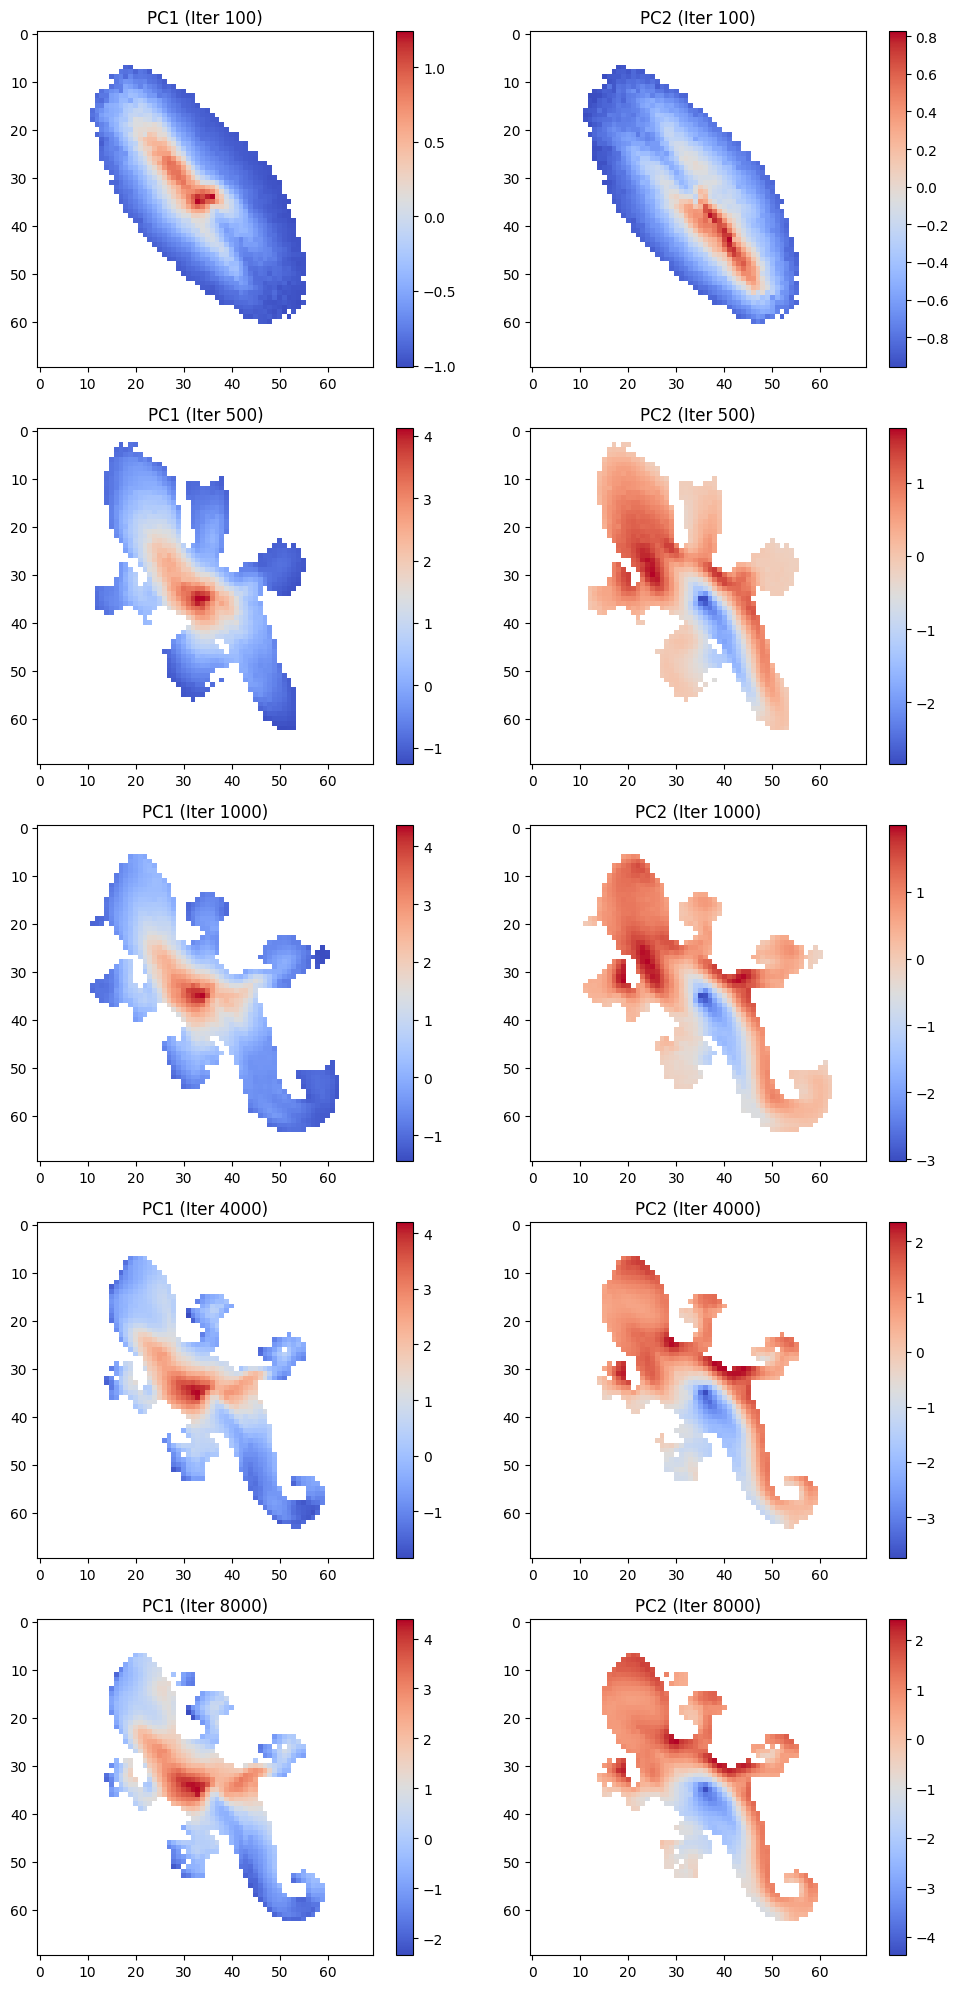

In [16]:
pca_maps_by_iter = {it: (PC1_map, PC2_map, alive_mask) for (it, PC1_map, PC2_map, alive_mask) in pca_maps}

requested_iters = [100, 500, 1000, 4000, 8000]
available_iters = [it for it in requested_iters if it in pca_maps_by_iter]

num_rows = len(available_iters)
num_cols = 2

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 4 * num_rows))

if num_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, it in enumerate(available_iters):
    PC1_map, PC2_map, alive_mask = pca_maps_by_iter[it]

    for col_idx, (pc_map, name) in enumerate(zip([PC1_map, PC2_map], ['PC1', 'PC2'])):
        ax = axes[row_idx, col_idx]
        masked = np.where(alive_mask, pc_map, np.nan)

        im = ax.imshow(masked, cmap='coolwarm')
        ax.set_title(f"{name} (Iter {it})")

        fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


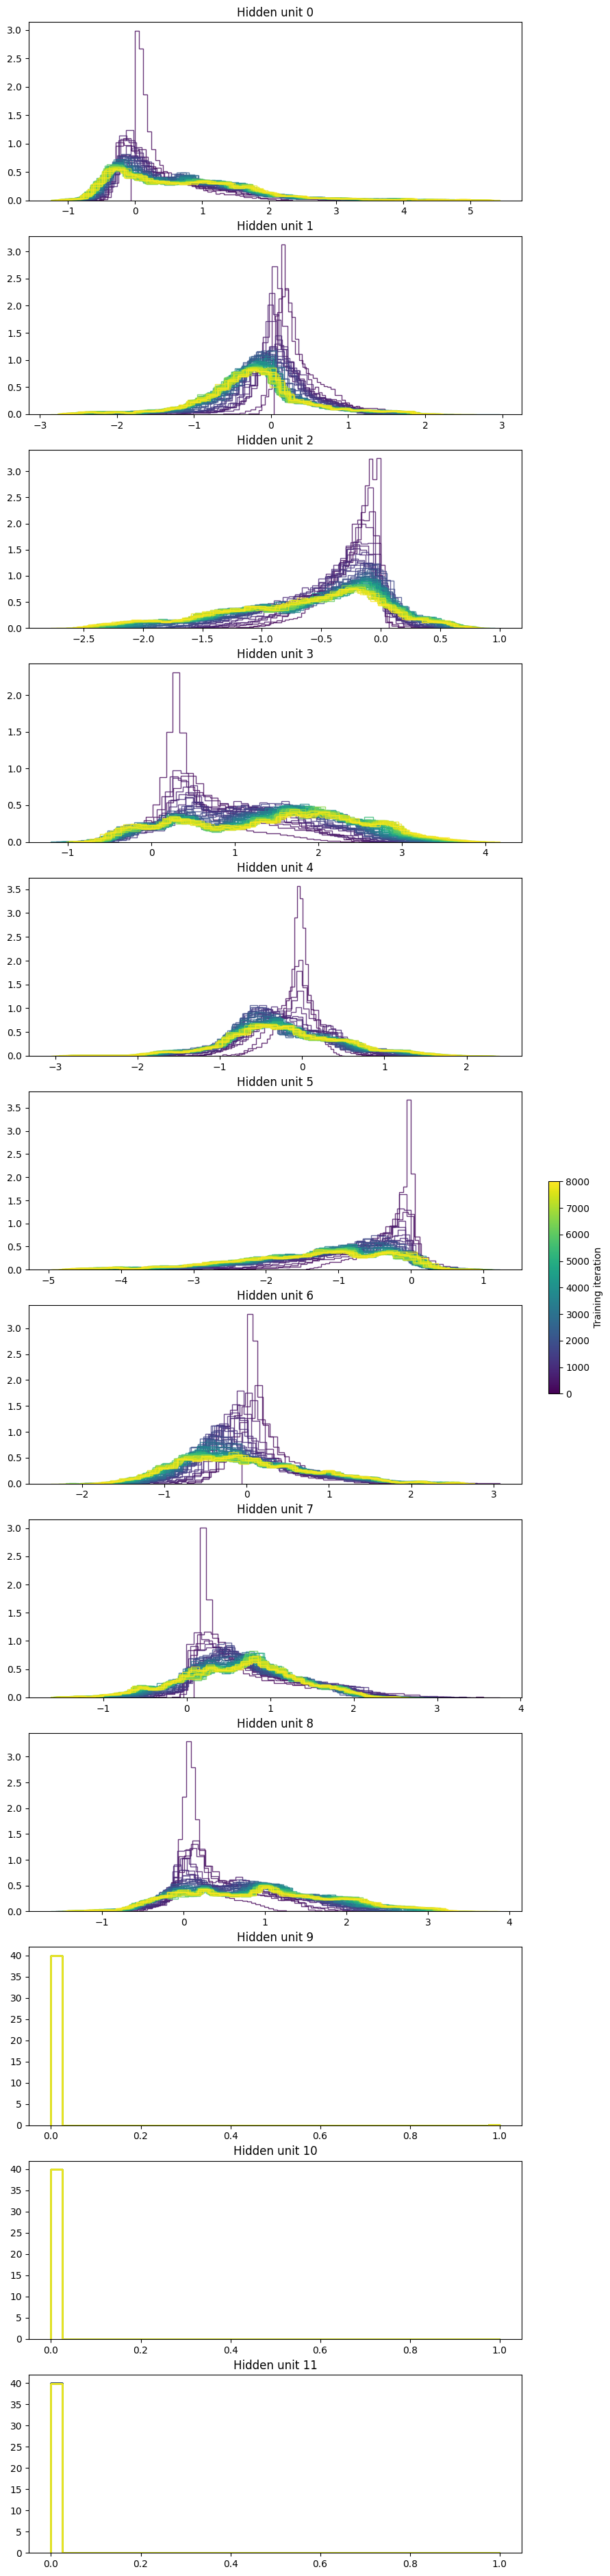

In [17]:
n_hidden = hidden_layers[0].shape[1]
n_snapshots = len(hidden_layers)
cmap = plt.cm.viridis

fig, axes = plt.subplots(n_hidden, 1, figsize=(10, 4*n_hidden), sharex=False)
for h_idx in range(n_hidden):
    ax = axes[h_idx]
    for snap_idx, (h_live, it) in enumerate(zip(hidden_layers, hidden_layers_iters)):
        color = cmap(snap_idx / max(n_snapshots - 1, 1))
        ax.hist(h_live[100:, h_idx], bins=40, density=True, histtype='step',
                 color=color, alpha=0.8)
    ax.set_title(f"Hidden unit {h_idx}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=hidden_layers_iters[0], vmax=hidden_layers_iters[-1]))
fig.colorbar(sm, ax=axes, label="Training iteration", fraction=0.02)
plt.show()

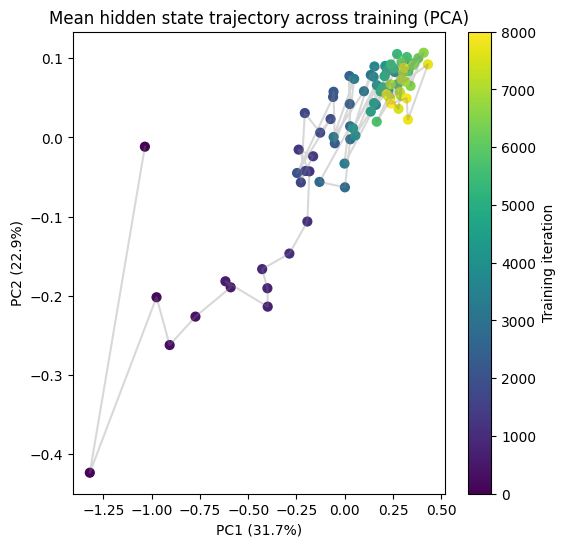

In [18]:

pooled = np.concatenate(hidden_layers, axis=0)
pca = PCA(n_components=2)
pca.fit(pooled)

means, stds = [], []
for h_live in hidden_layers:
    proj = pca.transform(h_live)
    means.append(proj.mean(axis=0))
    stds.append(proj.std(axis=0))
means = np.array(means)
stds = np.array(stds)

plt.figure(figsize=(6, 6))
sc = plt.scatter(means[:, 0], means[:, 1], c=hidden_layers_iters, cmap='viridis', s=40)
plt.plot(means[:, 0], means[:, 1], alpha=0.3, color='gray')
plt.colorbar(sc, label="Training iteration")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Mean hidden state trajectory across training (PCA)")
plt.show()

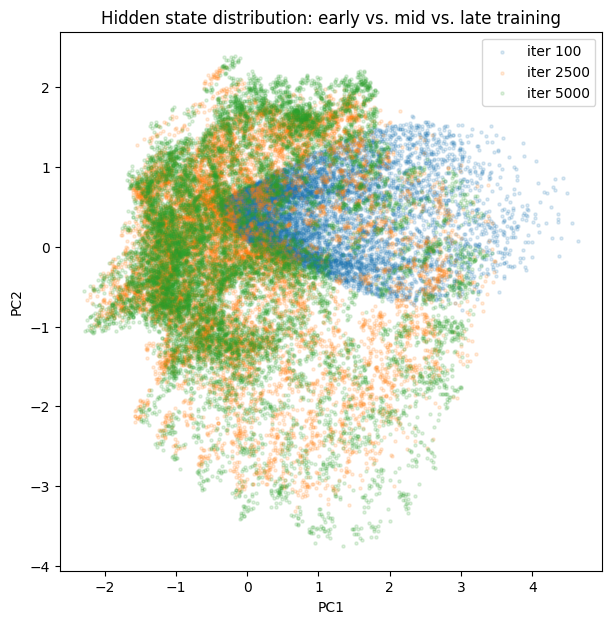

In [ ]:
plt.figure(figsize=(7, 7))
snap_indices_to_show = [1, len(hidden_layers)//2, len(hidden_layers)-1]
colors = ['tab:blue', 'tab:orange', 'tab:green']
for si, color in zip(snap_indices_to_show, colors):
    proj = pca.transform(hidden_layers[si])
    plt.scatter(proj[:, 0], proj[:, 1], alpha=0.15, s=5, color=color,
                label=f"iter {hidden_layers_iters[si]}")
plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hidden state distribution: early vs. mid vs. late training")
plt.show()

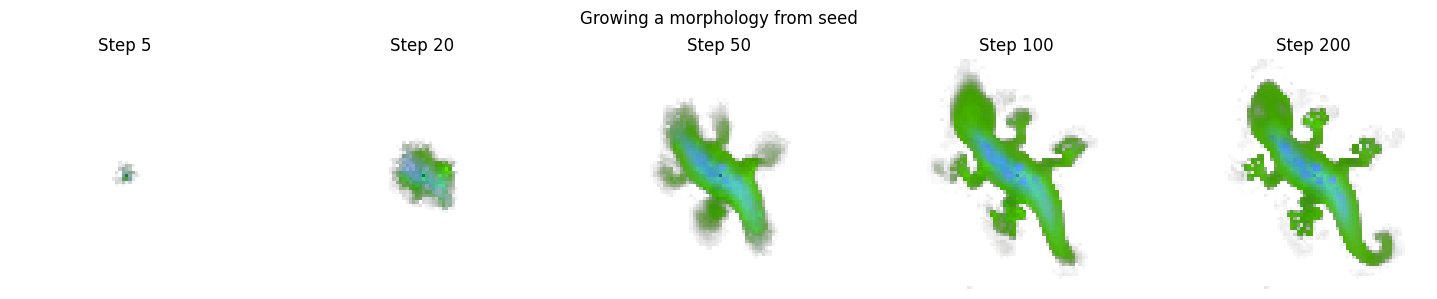

In [19]:
## Growing the morphology
def visualize_growth(nca, seed, steps_to_show=[5, 20, 50, 100, 200]):
    x = torch.from_numpy(seed[None, ...]).to(DEVICE) if isinstance(seed, np.ndarray) else seed.to(DEVICE)
    fig, axes = plt.subplots(1, len(steps_to_show), figsize=(15, 3))
    fig.suptitle("Growing a morphology from seed")

    current_step = 0
    with torch.no_grad():
        for i, target_step in enumerate(steps_to_show):
            steps_needed = target_step - current_step
            for _ in range(steps_needed):
                x = nca(x)
            current_step = target_step

            img = x[0, :4].permute(1, 2, 0).cpu().numpy()
            img = np.clip(img, 0, 1)
            axes[i].imshow(img)
            axes[i].set_title(f"Step {target_step}")
            axes[i].axis("off")

    plt.tight_layout()
    plt.show()

visualize_growth(nca, seed)





In [23]:
## Damage experiments

def apply_damage(x, damage_type='right_half', circle_radius=5):
    """
    Apply different damage patterns to a cell state.

    damage_type options:
        'right_half'   — remove right half (your original)
        'left_half'    — remove left half
        'center_circle'— remove a circle from the center
        'small_circle' — remove a small circle (severe local damage)
        'random'       — randomly zero out 50% of cells
        'cross'        — remove a cross through the center
    """
    x = x.clone()
    _, _, H, W = x.shape
    cy, cx = H // 2, W // 2  # center coordinates

    if damage_type == 'right_half':
        x[:, :, :, W//2:] = 0

    elif damage_type == 'left_half':
        x[:, :, :, :W//2] = 0

    elif damage_type == 'center_circle':
        # Remove a large circle from center
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) <= circle_radius**2
        x[:, :, mask] = 0

    elif damage_type == 'small_circle':
        # Severe: remove a tiny circle — forces regeneration from very little
        y_grid, x_grid = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
        mask = ((y_grid - cy)**2 + (x_grid - cx)**2) > circle_radius**2
        x[:, :, mask] = 0  # keep ONLY the small circle, destroy everything else

    elif damage_type == 'random':
        noise = torch.rand(1, 1, H, W, device=x.device) > 0.5
        x = x * noise.float()

    elif damage_type == 'cross':
        thickness = max(1, H // 10)
        x[:, :, cy - thickness:cy + thickness, :] = 0
        x[:, :, :, cx - thickness:cx + thickness] = 0

    return x



def visualize_regeneration(nca, seed, base, damage,
                            channels=4, steps=200, device=DEVICE):

    x = torch.from_numpy(seed[None, ...]).to(device) if isinstance(seed, np.ndarray) else seed.to(device)
    with torch.no_grad():
        for _ in range(500):
            x = nca(x)

    # Damage: remove right half
    x = apply_damage(x, damage)

    frames        = [x[0, :4].permute(1, 2, 0).cpu().clip(0, 1).numpy()]
    loss_recovery = []
    capture_steps = [25, 50, 100, 150, 199]

    with torch.no_grad():
        for t in range(steps):
            x = nca(x)
            l = (base[0:1] - x[:, :4]).pow(2).mean().item()
            loss_recovery.append(l)

            if t in capture_steps:
                frames.append(
                    x[0, :4].permute(1, 2, 0).cpu().clip(0, 1).numpy()
                )

    fig = plt.figure(figsize=(20, 9))

    titles = ['damaged'] + [f't={t}' for t in capture_steps]
    for i, (frame, title) in enumerate(zip(frames, titles)):
        ax = fig.add_subplot(2, len(frames), i + 1)
        ax.imshow(frame)
        ax.set_title(title)
        ax.axis('off')

    ax_loss = fig.add_subplot(2, 2, 3)
    ax_loss.plot(loss_recovery, color='blue', linewidth=1.5)
    ax_loss.set_title("Reconstruction Loss During Recovery")
    ax_loss.set_xlabel("NCA Steps")
    ax_loss.set_ylabel("MSE Loss")
    ax_loss.grid(True, alpha=0.3)
    for t in capture_steps:
        ax_loss.axvline(x=t, color='gray', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()



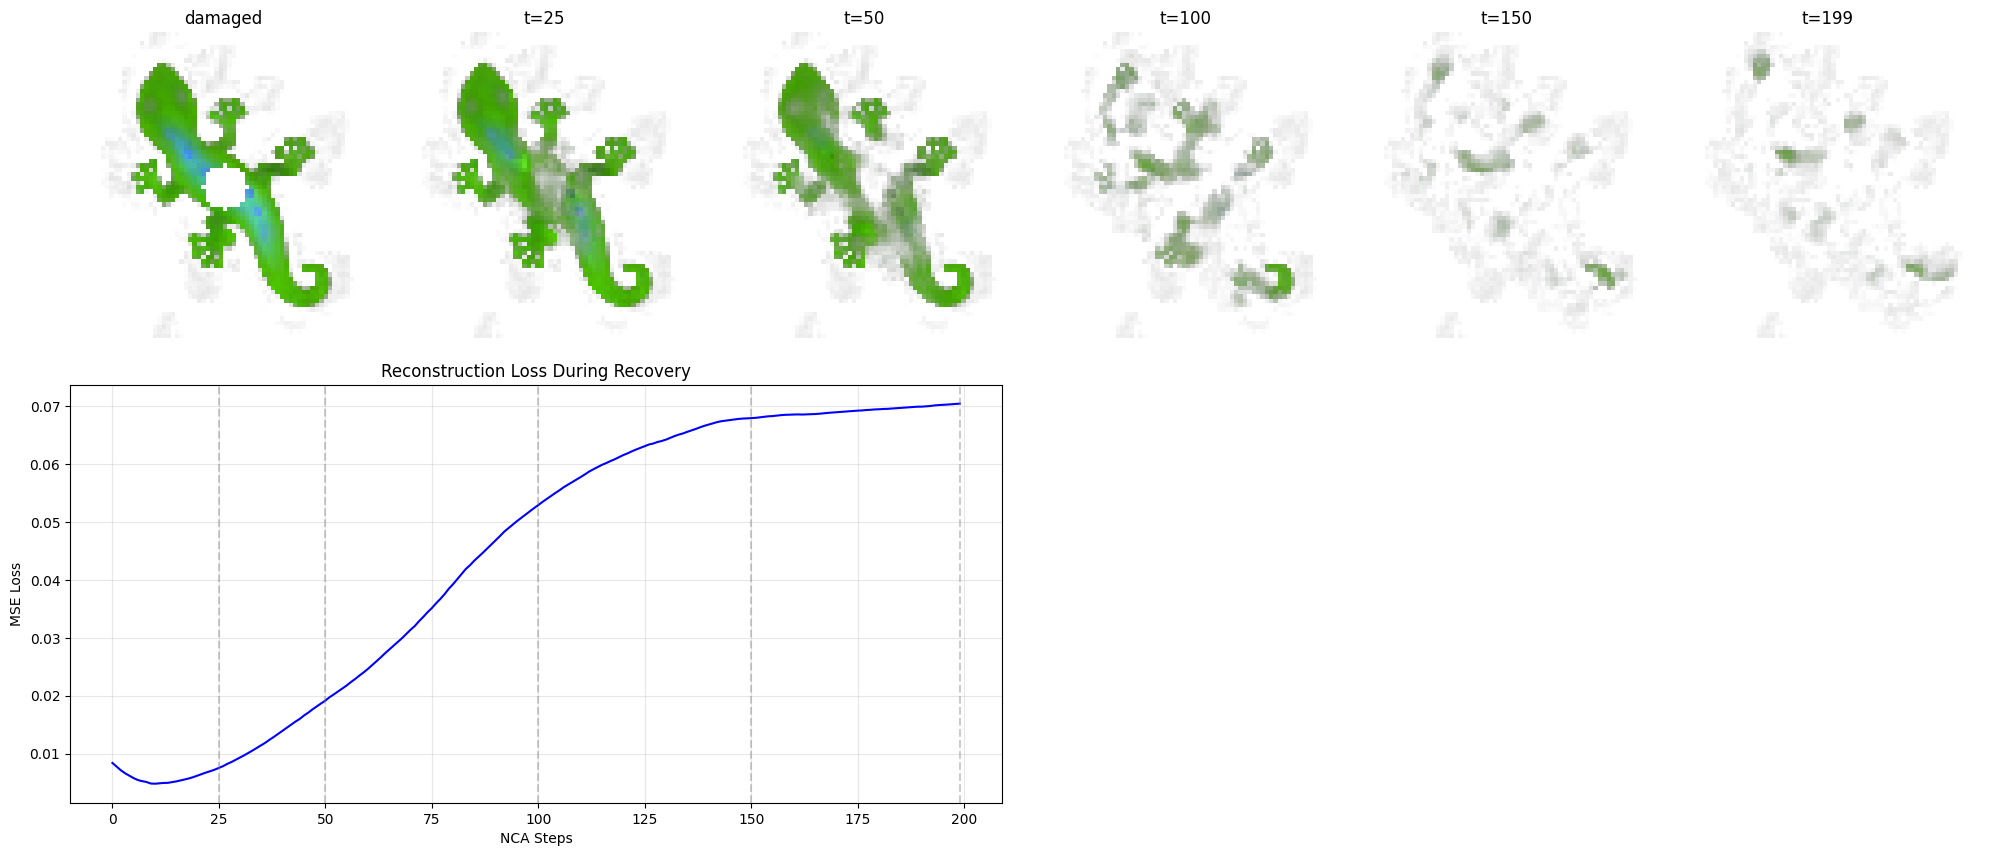

In [24]:
visualize_regeneration(nca, seed, base, "center_circle")

In [ ]:
del nca
del optim
torch.cuda.empty_cache()